# Autism Spectrum Disorder Detection - ViT and CNN Models Training

This notebook prepares data from the AutismDataset folder and trains Vision Transformer and various CNN architectures for autism spectrum disorder detection:
- Vision Transformer (ViT)
- AlexNet
- MobileNet V2
- DenseNet-121
- RegNet

## Import Libraries

In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.optim as optim
import torchvision.models as models
import time
import copy
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import glob
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## Data Preparation

We'll create DataFrames for train, validation, and test sets from the AutismDataset folder structure.

In [13]:
def read_img(child_folder, parent_path):
    image_path = []
    label = []
    directory = f"{parent_path}/{child_folder}"
    for label_folder in os.listdir(directory):
        label_dir = f"{directory}/{label_folder}"
        for image_file in os.listdir(label_dir):
            if image_file.lower().endswith(('.jpg','.png')):
                image_path.append(f"{label_dir}/{image_file}")
                label.append(label_folder)
    data = pd.DataFrame(zip(image_path, label), columns=["image_path", "labels"])
    return data

def prepare_data(child_folder):
    """Prepares the data by reading images from the specified folders.

    Args:
        parent_folder (str): The name of the parent folder containing the dataset.
        child_folder (str): The name of the child folder containing the images.

    Returns:
        pd.DataFrame: A DataFrame containing image paths and their corresponding labels.
    """
    parent_path = "/kaggle/input/autistic-children-facial-image-dataset"
    data = read_img(child_folder,parent_path)
    return data

# Create DataFrames for each split
print("Creating train DataFrame...")
train_df = prepare_data('train')

print("Creating validation DataFrame...")
valid_df = prepare_data('valid')

print("Creating test DataFrame...")
test_df = prepare_data('test')

# Display dataset statistics
print(f"\nDataset Statistics:")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(valid_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Total samples: {len(train_df) + len(valid_df) + len(test_df)}")

print(f"\nLabel distribution in training set:")
print(train_df['labels'].value_counts())

print(f"\nLabel distribution in validation set:")
print(valid_df['labels'].value_counts())

print(f"\nLabel distribution in test set:")
print(test_df['labels'].value_counts())

Creating train DataFrame...
Creating validation DataFrame...
Creating test DataFrame...

Dataset Statistics:
Training samples: 2526
Validation samples: 200
Test samples: 200
Total samples: 2926

Label distribution in training set:
labels
autistic        1263
non_autistic    1263
Name: count, dtype: int64

Label distribution in validation set:
labels
autistic        100
non_autistic    100
Name: count, dtype: int64

Label distribution in test set:
labels
autistic        100
non_autistic    100
Name: count, dtype: int64


## Data Transformations

Define image transformations for training and validation/testing. For ViT models, we use specific image sizes.

In [14]:
# Data transformations for CNN models
train_transform_cnn = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

val_test_transform_cnn = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

## Dataset & DataLoader Classes

In [15]:
BATCH_SIZE = 16
NUM_WORKERS = 4

class AutismDataset(Dataset):
    def __init__(self, dataframe, transform=None, label_encoder=None, fit_label_encoder=False):
        """
        Args:
            dataframe (DataFrame): DataFrame with image_path and labels columns.
            transform (callable, optional): Optional transform to be applied on a sample.
            label_encoder (LabelEncoder, optional): Pre-fitted label encoder. If None, creates new one.
            fit_label_encoder (bool): Whether to fit the label encoder on this dataset's labels.
        """
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform
        
        if label_encoder is None:
            self.label_encoder = LabelEncoder()
            if fit_label_encoder:
                self.labels = self.label_encoder.fit_transform(self.data['labels'])
            else:
                raise ValueError("Must provide label_encoder or set fit_label_encoder=True")
        else:
            self.label_encoder = label_encoder
            self.labels = self.label_encoder.transform(self.data['labels'])
        
        self.image_paths = self.data['image_path'].tolist()
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # Load image
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image: {img_path}")
            image = Image.new('RGB', (224, 224), color='black')
        
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)
    
    def get_label_encoder(self):
        """Return the label encoder for use with other datasets"""
        return self.label_encoder
    
    def get_class_names(self):
        """Return the original class names"""
        return self.label_encoder.classes_

def create_dataloaders(train_df, val_df, test_df, train_transform, val_test_transform, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    """
    Create datasets and dataloaders for training, validation, and testing
    """
    # Create training dataset and fit label encoder
    train_dataset = AutismDataset(
        dataframe=train_df, 
        transform=train_transform,
        fit_label_encoder=True  
    )
    
    # Get the fitted label encoder
    le = train_dataset.get_label_encoder()
    
    # Create validation dataset using the same label encoder
    val_dataset = AutismDataset(
        dataframe=val_df,
        transform=val_test_transform,
        label_encoder=le
    )
    
    # Create test dataset using the same label encoder
    test_dataset = AutismDataset(
        dataframe=test_df,
        transform=val_test_transform,
        label_encoder=le
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader, test_loader, le

## Model Training Framework

In [16]:
class ModelTrainer:
    def __init__(self, model, train_loader, val_loader, test_loader, device='cuda'):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        
        # Training history
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
    def train_model(self, num_epochs=25, lr=0.001, weight_decay=1e-4, save_best=True, model_name="model"):
        """Train the model with early stopping and best model saving"""
        
        # Loss function and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
        
        # Best model tracking
        best_val_acc = 0.0
        best_model_wts = copy.deepcopy(self.model.state_dict())
        patience = 5
        patience_counter = 0
        
        print(f"Starting training for {num_epochs} epochs...")
        print("-" * 60)
        
        start_time = time.time()
        
        for epoch in range(num_epochs):
            print(f'Epoch {epoch+1}/{num_epochs}')
            print('-' * 10)
            
            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    self.model.train()
                    dataloader = self.train_loader
                else:
                    self.model.eval()
                    dataloader = self.val_loader
                
                running_loss = 0.0
                running_corrects = 0
                total_samples = 0
                
                # Progress bar
                pbar = tqdm(dataloader, desc=f'{phase.capitalize()} ')
                
                for inputs, labels in pbar:
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device)
                    
                    # Zero gradients
                    optimizer.zero_grad()
                    
                    # Forward pass
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = self.model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)
                        
                        # Backward pass (only in training)
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                    
                    # Statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                    total_samples += inputs.size(0)
                    
                    # Update progress bar
                    current_acc = running_corrects.double() / total_samples
                    pbar.set_postfix({
                        'Loss': f'{running_loss/total_samples:.4f}',
                        'Acc': f'{current_acc:.4f}'
                    })
                
                # Calculate epoch metrics
                epoch_loss = running_loss / total_samples
                epoch_acc = running_corrects.double() / total_samples
                
                print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
                
                # Store metrics
                if phase == 'train':
                    self.train_losses.append(epoch_loss)
                    self.train_accuracies.append(epoch_acc.cpu())
                else:
                    self.val_losses.append(epoch_loss)
                    self.val_accuracies.append(epoch_acc.cpu())
                
                # Save best model
                if phase == 'val' and epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(self.model.state_dict())
                    patience_counter = 0
                    if save_best:
                        torch.save(self.model.state_dict(), f'best_{model_name}.pth')
                        print(f'✓ New best model saved with validation accuracy: {best_val_acc:.4f}')
                elif phase == 'val':
                    patience_counter += 1
            
            # Learning rate scheduler step
            if phase == 'train':
                scheduler.step()
            
            # Early stopping
            if patience_counter >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs')
                break
                
            print()
        
        # Training complete
        time_elapsed = time.time() - start_time
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best validation accuracy: {best_val_acc:.4f}')
        
        # Load best model weights
        self.model.load_state_dict(best_model_wts)
        return self.model
    
    def evaluate_model(self, test_loader=None):
        """Evaluate model on test set"""
        if test_loader is None:
            test_loader = self.test_loader
            
        self.model.eval()
        all_preds = []
        all_labels = []
        test_loss = 0.0
        correct = 0
        total = 0
        
        criterion = nn.CrossEntropyLoss()
        
        print("Evaluating on test set...")
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader):
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                test_loss += loss.item()
                
                # Store for detailed metrics
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Calculate metrics
        test_acc = 100 * correct / total
        avg_test_loss = test_loss / len(test_loader)
        
        print(f'Test Accuracy: {test_acc:.2f}%')
        print(f'Test Loss: {avg_test_loss:.4f}')
        
        # Detailed classification report
        print("\nClassification Report:")
        print(classification_report(all_labels, all_preds, target_names=['Autistic', 'Non_Autistic']))
        
        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        print(f"\nConfusion Matrix:")
        print(cm)
        
        return test_acc, all_preds, all_labels
    
    def plot_training_history(self, save_path=None):
        """Plot training and validation metrics"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Plot losses
        ax1.plot(self.train_losses, label='Train Loss', marker='o')
        ax1.plot(self.val_losses, label='Validation Loss', marker='s')
        ax1.set_title('Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)
        
        # Plot accuracies
        ax2.plot(self.train_accuracies, label='Train Accuracy', marker='o')
        ax2.plot(self.val_accuracies, label='Validation Accuracy', marker='s')
        ax2.set_title('Model Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path)
        plt.show()

## Model Definitions

In [17]:
def create_vit_model(architecture='vit_b_16', num_classes=2, pretrained=True):
    """Create Vision Transformer model for binary classification"""
    if architecture == 'vit_b_16':
        model = models.vit_b_16(pretrained=pretrained)
    elif architecture == 'vit_l_16':
        model = models.vit_l_16(pretrained=pretrained)
    else:
        raise ValueError("Architecture must be 'vit_b_16' or 'vit_l_16'")
    
    # Modify classifier head
    num_features = model.heads.head.in_features
    model.heads.head = nn.Linear(num_features, num_classes)
    
    return model

def create_alexnet_model(num_classes=2, pretrained=True):
    """Create AlexNet model for binary classification"""
    model = models.alexnet(pretrained=pretrained)
    
    # Modify classifier
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_features, num_classes)
    
    return model

def create_mobilenet_model(version='v2', num_classes=2, pretrained=True):
    """Create MobileNet model (v2 or v3) for binary classification"""
    if version == 'v2':
        model = models.mobilenet_v2(pretrained=pretrained)
        # Modify classifier
        num_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_features, num_classes)
    elif version == 'v3_large':
        model = models.mobilenet_v3_large(pretrained=pretrained)
        # Modify classifier
        num_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(num_features, num_classes)
    elif version == 'v3_small':
        model = models.mobilenet_v3_small(pretrained=pretrained)
        # Modify classifier
        num_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(num_features, num_classes)
    else:
        raise ValueError("Version must be 'v2', 'v3_large', or 'v3_small'")
    
    return model

def create_regnet_model(architecture='x_400mf', num_classes=2, pretrained=True):
    """Create RegNet model for binary classification"""
    if architecture == 'x_400mf':
        model = models.regnet_x_400mf(pretrained=pretrained)
    elif architecture == 'x_800mf':
        model = models.regnet_x_800mf(pretrained=pretrained)
    elif architecture == 'y_400mf':
        model = models.regnet_y_400mf(pretrained=pretrained)
    elif architecture == 'y_800mf':
        model = models.regnet_y_800mf(pretrained=pretrained)
    else:
        raise ValueError("Architecture must be 'x_400mf', 'x_800mf', 'y_400mf', or 'y_800mf'")
    
    # Modify classifier
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

def create_densenet_model(architecture='121', num_classes=2, pretrained=True):
    """Create DenseNet model (121 or 169) for binary classification"""
    if architecture == '121':
        model = models.densenet121(pretrained=pretrained)
    elif architecture == '169':
        model = models.densenet169(pretrained=pretrained)
    else:
        raise ValueError("Architecture must be '121' or '169'")
    
    # Modify classifier
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, num_classes)
    
    return model

## Configure GPU

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 15.9 GB


## Create DataLoaders for CNN Models

In [19]:
# Create CNN dataloaders
train_loader_cnn, val_loader_cnn, test_loader_cnn, label_encoder = create_dataloaders(
    train_df, valid_df, test_df, 
    train_transform_cnn, val_test_transform_cnn,
    batch_size=32, num_workers=4
)

print(f"CNN DataLoaders created:")
print(f"Training batches: {len(train_loader_cnn)}")
print(f"Validation batches: {len(val_loader_cnn)}")
print(f"Test batches: {len(test_loader_cnn)}")
print(f"Classes: {label_encoder.classes_}")

CNN DataLoaders created:
Training batches: 78
Validation batches: 7
Test batches: 7
Classes: ['autistic' 'non_autistic']


## Create DataLoaders for ViT Model

In [20]:
# Create ViT dataloaders (larger image size)
train_loader_vit, val_loader_vit, test_loader_vit, _ = create_dataloaders(
    train_df, valid_df, test_df, 
    train_transform_cnn, val_test_transform_cnn,
    batch_size=16, num_workers=4  # Smaller batch size for ViT due to memory requirements
)

print(f"ViT DataLoaders created:")
print(f"Training batches: {len(train_loader_vit)}")
print(f"Validation batches: {len(val_loader_vit)}")
print(f"Test batches: {len(test_loader_vit)}")

ViT DataLoaders created:
Training batches: 157
Validation batches: 13
Test batches: 13


## 1. Vision Transformer (ViT-B/16) Training

In [21]:
# Create and train ViT-B/16
print("Creating Vision Transformer (ViT-B/16) model...")
vit_b16_model = create_vit_model('vit_b_16')
vit_b16_trainer = ModelTrainer(vit_b16_model, train_loader_vit, val_loader_vit, test_loader_vit, device)

Creating Vision Transformer (ViT-B/16) model...


In [22]:
# Train ViT-B/16
print("Training Vision Transformer (ViT-B/16)...")
trained_vit_b16 = vit_b16_trainer.train_model(num_epochs=25, lr=0.0001, model_name="vit_b16")

Training Vision Transformer (ViT-B/16)...
Starting training for 25 epochs...
------------------------------------------------------------
Epoch 1/25
----------


Train : 100%|██████████| 157/157 [00:51<00:00,  3.04it/s, Loss=0.5757, Acc=0.7086]


Train Loss: 0.5757 Acc: 0.7086


Val : 100%|██████████| 13/13 [00:01<00:00,  7.45it/s, Loss=0.5235, Acc=0.8000]


Val Loss: 0.5235 Acc: 0.8000
✓ New best model saved with validation accuracy: 0.8000

Epoch 2/25
----------


...

Val Loss: 0.5285 Acc: 0.7550

Epoch 8/25
----------


Train : 100%|██████████| 157/157 [00:50<00:00,  3.11it/s, Loss=0.3565, Acc=0.8424]


Train Loss: 0.3565 Acc: 0.8424


Val : 100%|██████████| 13/13 [00:01<00:00,  7.96it/s, Loss=0.5688, Acc=0.7150]

Val Loss: 0.5688 Acc: 0.7150
Early stopping triggered after 8 epochs
Training complete in 7m 0s
Best validation accuracy: 0.8050


Evaluating on test set...


100%|██████████| 13/13 [00:01<00:00,  8.75it/s]


Test Accuracy: 89.50%
Test Loss: 0.3253

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.88      0.91      0.90       100
Non_Autistic       0.91      0.88      0.89       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200


Confusion Matrix:
[[91  9]
 [12 88]]


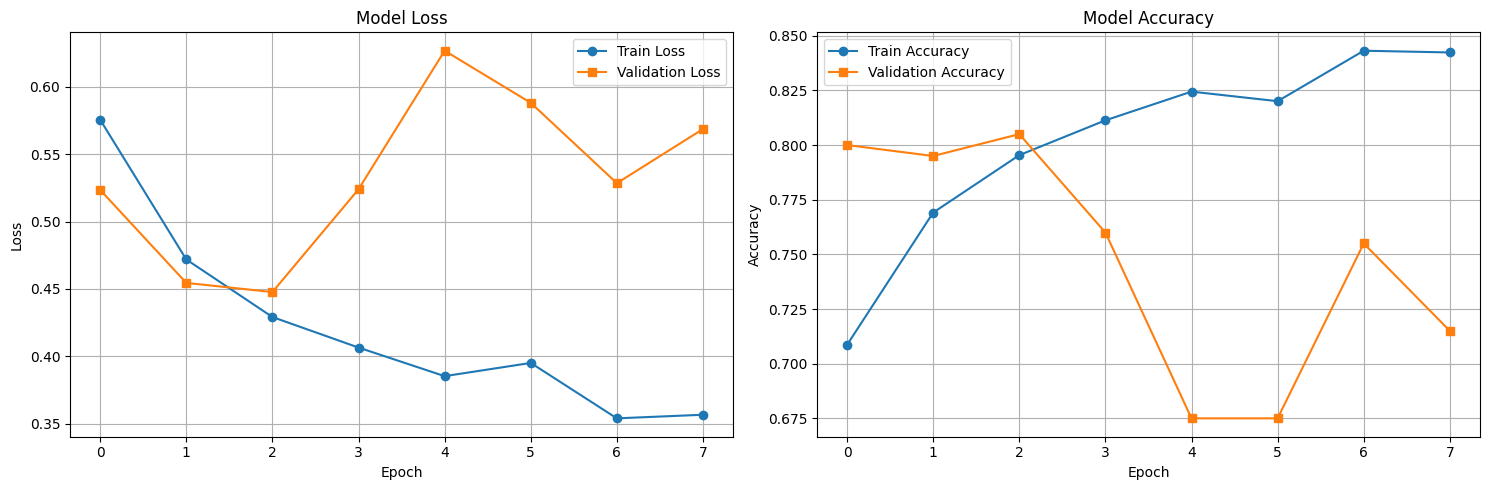

In [23]:
# Evaluate ViT-B/16
vit_b16_test_acc, vit_b16_preds, vit_b16_labels = vit_b16_trainer.evaluate_model()
vit_b16_trainer.plot_training_history()

## 2. AlexNet Training

In [24]:
# Create and train AlexNet
print("Creating AlexNet model...")
alexnet_model = create_alexnet_model()
alexnet_trainer = ModelTrainer(alexnet_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Creating AlexNet model...


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 217MB/s] 


In [25]:
# Train AlexNet
print("Training AlexNet...")
trained_alexnet = alexnet_trainer.train_model(num_epochs=25, model_name="alexnet")

Training AlexNet...
Starting training for 25 epochs...
------------------------------------------------------------
Epoch 1/25
----------


Train : 100%|██████████| 78/78 [00:10<00:00,  7.34it/s, Loss=0.7714, Acc=0.5008]


Train Loss: 0.7714 Acc: 0.5008


Val : 100%|██████████| 7/7 [00:00<00:00,  9.27it/s, Loss=0.6932, Acc=0.5000]


Val Loss: 0.6932 Acc: 0.5000
✓ New best model saved with validation accuracy: 0.5000

Epoch 2/25
----------


...

Val Loss: 0.6938 Acc: 0.5000

Epoch 6/25
----------


Train : 100%|██████████| 78/78 [00:10<00:00,  7.54it/s, Loss=0.6961, Acc=0.4844]


Train Loss: 0.6961 Acc: 0.4844


Val : 100%|██████████| 7/7 [00:00<00:00,  8.18it/s, Loss=0.6937, Acc=0.5000]

Val Loss: 0.6937 Acc: 0.5000
Early stopping triggered after 6 epochs
Training complete in 1m 8s
Best validation accuracy: 0.5000


Evaluating on test set...


100%|██████████| 7/7 [00:00<00:00, 12.09it/s]


Test Accuracy: 50.00%
Test Loss: 0.6929

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.00      0.00      0.00       100
Non_Autistic       0.50      1.00      0.67       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200


Confusion Matrix:
[[  0 100]
 [  0 100]]


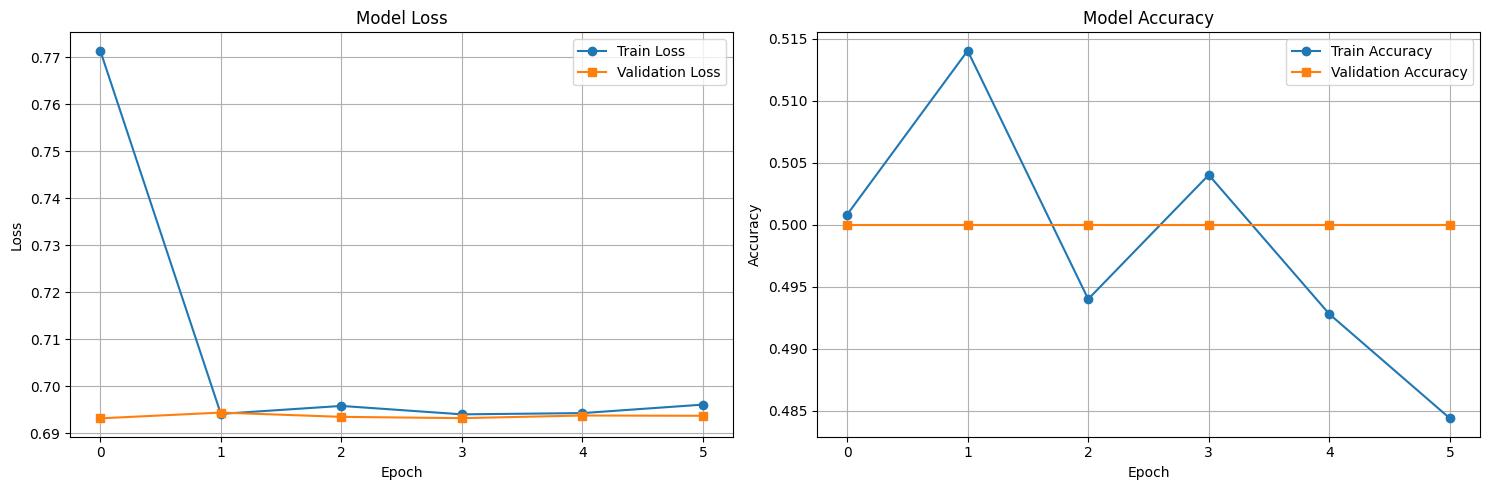

In [26]:
# Evaluate AlexNet
alexnet_test_acc, alexnet_preds, alexnet_labels = alexnet_trainer.evaluate_model()
alexnet_trainer.plot_training_history()

## 3. MobileNet V2 Training

In [27]:
# Create and train MobileNet V2
print("Creating MobileNet V2 model...")
mobilenet_v2_model = create_mobilenet_model('v2')
mobilenet_v2_trainer = ModelTrainer(mobilenet_v2_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


Creating MobileNet V2 model...


100%|██████████| 13.6M/13.6M [00:00<00:00, 166MB/s]


In [28]:
# Train MobileNet V2
print("Training MobileNet V2...")
trained_mobilenet_v2 = mobilenet_v2_trainer.train_model(num_epochs=25, model_name="mobilenet_v2")

Training MobileNet V2...
Starting training for 25 epochs...
------------------------------------------------------------
Epoch 1/25
----------


Train : 100%|██████████| 78/78 [00:11<00:00,  6.69it/s, Loss=0.5687, Acc=0.7163]


Train Loss: 0.5687 Acc: 0.7163


Val : 100%|██████████| 7/7 [00:00<00:00,  8.51it/s, Loss=0.5316, Acc=0.7650]


Val Loss: 0.5316 Acc: 0.7650
✓ New best model saved with validation accuracy: 0.7650

Epoch 2/25
----------


...

Val Loss: 0.5673 Acc: 0.7450

Epoch 7/25
----------


Train : 100%|██████████| 78/78 [00:11<00:00,  6.93it/s, Loss=0.3545, Acc=0.8478]


Train Loss: 0.3545 Acc: 0.8478


Val : 100%|██████████| 7/7 [00:00<00:00,  8.85it/s, Loss=0.4568, Acc=0.7600]


Val Loss: 0.4568 Acc: 0.7600
Early stopping triggered after 7 epochs
Training complete in 1m 26s
Best validation accuracy: 0.8050


Evaluating on test set...


100%|██████████| 7/7 [00:00<00:00, 11.23it/s]


Test Accuracy: 80.00%
Test Loss: 0.3923

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.81      0.78      0.80       100
Non_Autistic       0.79      0.82      0.80       100

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200


Confusion Matrix:
[[78 22]
 [18 82]]


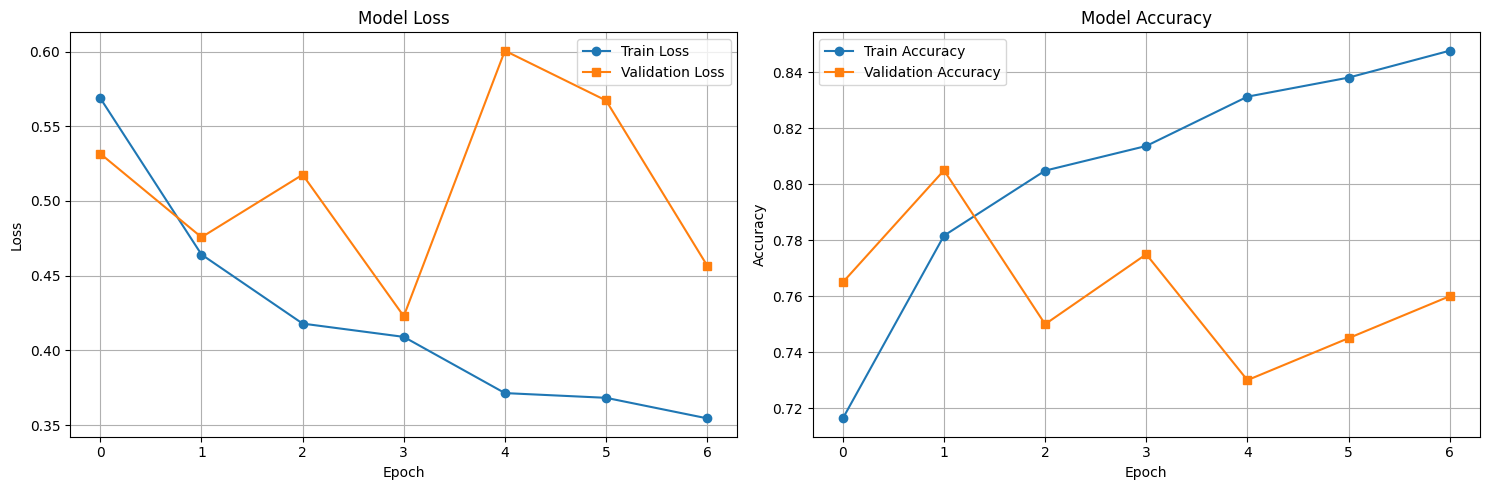

In [29]:
# Evaluate MobileNet V2
mobilenet_v2_test_acc, mobilenet_v2_preds, mobilenet_v2_labels = mobilenet_v2_trainer.evaluate_model()
mobilenet_v2_trainer.plot_training_history()

## 4. MobileNet V3 Large Training

In [30]:
# Create and train MobileNet V3 Large
print("Creating MobileNet V3 Large model...")
mobilenet_v3_large_model = create_mobilenet_model('v3_large')
mobilenet_v3_large_trainer = ModelTrainer(mobilenet_v3_large_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


Creating MobileNet V3 Large model...


100%|██████████| 21.1M/21.1M [00:00<00:00, 172MB/s]


In [31]:
# Train MobileNet V3 Large
print("Training MobileNet V3 Large...")
trained_mobilenet_v3_large = mobilenet_v3_large_trainer.train_model(num_epochs=25, model_name="mobilenet_v3_large")

Training MobileNet V3 Large...
Starting training for 25 epochs...
------------------------------------------------------------
Epoch 1/25
----------


Train : 100%|██████████| 78/78 [00:10<00:00,  7.09it/s, Loss=0.5222, Acc=0.7448]


Train Loss: 0.5222 Acc: 0.7448


Val : 100%|██████████| 7/7 [00:00<00:00,  8.73it/s, Loss=0.6545, Acc=0.7150]


Val Loss: 0.6545 Acc: 0.7150
✓ New best model saved with validation accuracy: 0.7150

Epoch 2/25
----------


...

Val Loss: 0.5477 Acc: 0.7550

Epoch 8/25
----------


Train : 100%|██████████| 78/78 [00:11<00:00,  7.00it/s, Loss=0.2671, Acc=0.8842]


Train Loss: 0.2671 Acc: 0.8842


Val : 100%|██████████| 7/7 [00:00<00:00,  8.30it/s, Loss=0.4887, Acc=0.7600]


Val Loss: 0.4887 Acc: 0.7600
Early stopping triggered after 8 epochs
Training complete in 1m 36s
Best validation accuracy: 0.7650


Evaluating on test set...


100%|██████████| 7/7 [00:00<00:00, 10.91it/s]


Test Accuracy: 80.50%
Test Loss: 0.3903

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.91      0.68      0.78       100
Non_Autistic       0.74      0.93      0.83       100

    accuracy                           0.81       200
   macro avg       0.83      0.81      0.80       200
weighted avg       0.83      0.81      0.80       200


Confusion Matrix:
[[68 32]
 [ 7 93]]


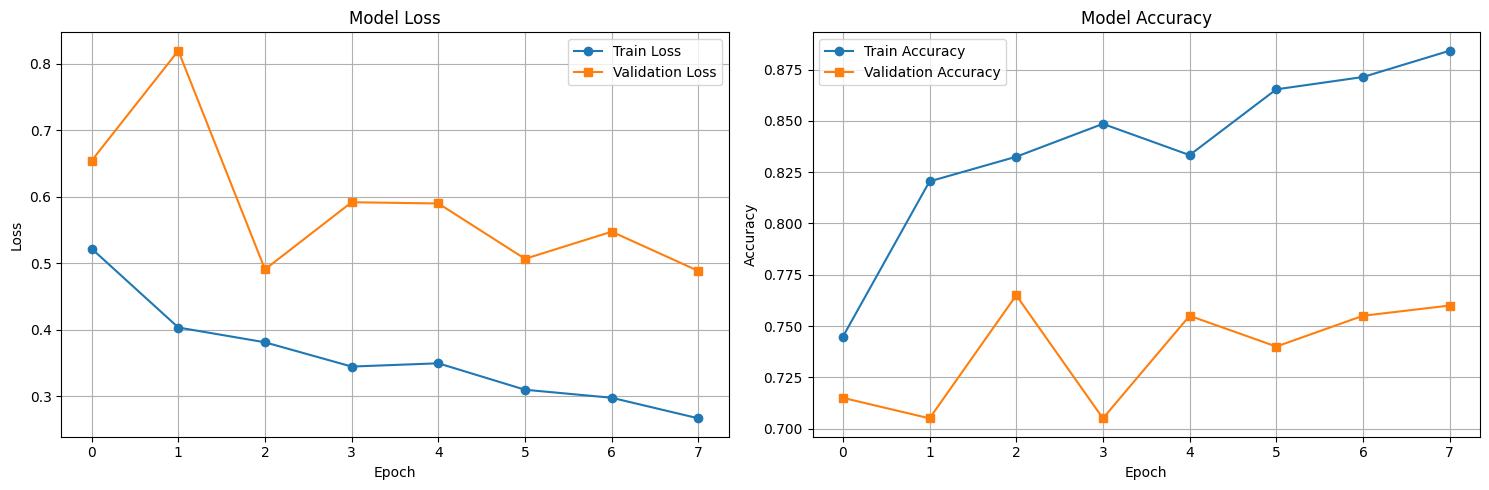

In [32]:
# Evaluate MobileNet V3 Large
mobilenet_v3_large_test_acc, mobilenet_v3_large_preds, mobilenet_v3_large_labels = mobilenet_v3_large_trainer.evaluate_model()
mobilenet_v3_large_trainer.plot_training_history()

## 5. RegNet X-400MF Training

In [33]:
# Create and train RegNet X-400MF
print("Creating RegNet X-400MF model...")
regnet_x_400mf_model = create_regnet_model('x_400mf')
regnet_x_400mf_trainer = ModelTrainer(regnet_x_400mf_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Downloading: "https://download.pytorch.org/models/regnet_x_400mf-adf1edd5.pth" to /root/.cache/torch/hub/checkpoints/regnet_x_400mf-adf1edd5.pth


Creating RegNet X-400MF model...


100%|██████████| 21.3M/21.3M [00:00<00:00, 182MB/s]


In [34]:
# Train RegNet X-400MF
print("Training RegNet X-400MF...")
trained_regnet_x_400mf = regnet_x_400mf_trainer.train_model(num_epochs=25, model_name="regnet_x_400mf")

Training RegNet X-400MF...
Starting training for 25 epochs...
------------------------------------------------------------
Epoch 1/25
----------


Train : 100%|██████████| 78/78 [00:11<00:00,  6.83it/s, Loss=0.5602, Acc=0.7212]


Train Loss: 0.5602 Acc: 0.7212


Val : 100%|██████████| 7/7 [00:00<00:00,  8.15it/s, Loss=0.5606, Acc=0.7350]


Val Loss: 0.5606 Acc: 0.7350
✓ New best model saved with validation accuracy: 0.7350

Epoch 2/25
----------


...

Val Loss: 0.6073 Acc: 0.7300

Epoch 11/25
----------


Train : 100%|██████████| 78/78 [00:11<00:00,  6.81it/s, Loss=0.2576, Acc=0.8894]


Train Loss: 0.2576 Acc: 0.8894


Val : 100%|██████████| 7/7 [00:00<00:00,  8.72it/s, Loss=0.6131, Acc=0.7700]


Val Loss: 0.6131 Acc: 0.7700
Early stopping triggered after 11 epochs
Training complete in 2m 15s
Best validation accuracy: 0.8300


Evaluating on test set...


100%|██████████| 7/7 [00:00<00:00, 11.21it/s]


Test Accuracy: 84.00%
Test Loss: 0.3159

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.85      0.82      0.84       100
Non_Autistic       0.83      0.86      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200


Confusion Matrix:
[[82 18]
 [14 86]]


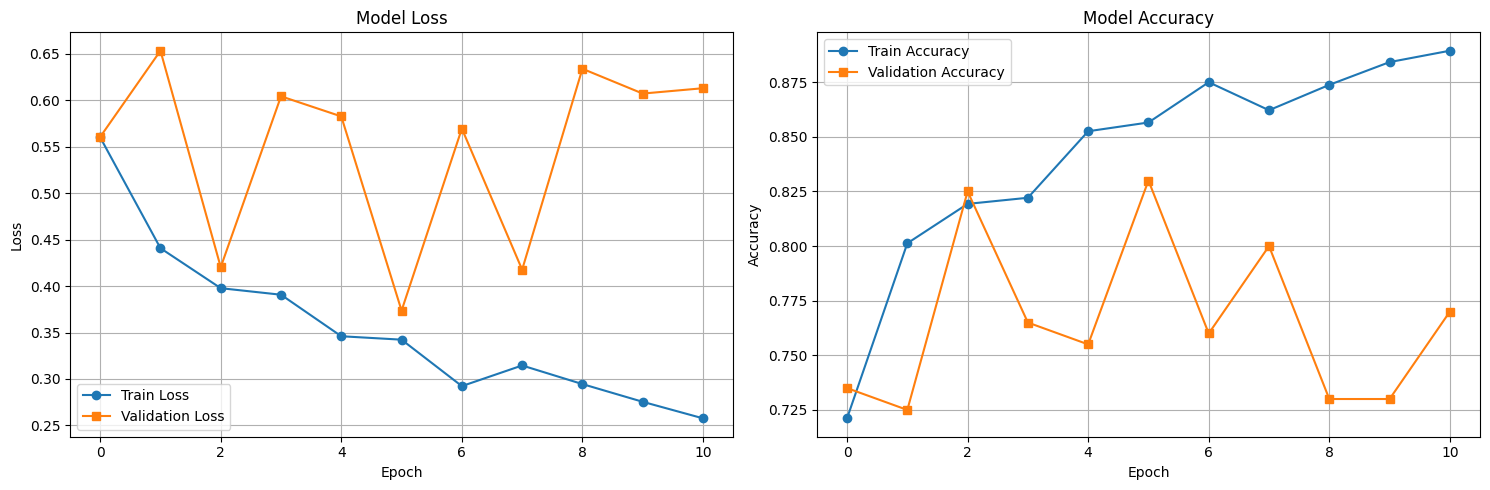

In [35]:
# Evaluate RegNet X-400MF
regnet_x_400mf_test_acc, regnet_x_400mf_preds, regnet_x_400mf_labels = regnet_x_400mf_trainer.evaluate_model()
regnet_x_400mf_trainer.plot_training_history()

## 6. DenseNet-121 Training

In [36]:
# Create and train DenseNet-121
print("Creating DenseNet-121 model...")
densenet121_model = create_densenet_model('121')
densenet121_trainer = ModelTrainer(densenet121_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


Creating DenseNet-121 model...


100%|██████████| 30.8M/30.8M [00:00<00:00, 189MB/s]


In [37]:
# Train DenseNet-121
print("Training DenseNet-121...")
trained_densenet121 = densenet121_trainer.train_model(num_epochs=25, model_name="densenet121")

Training DenseNet-121...
Starting training for 25 epochs...
------------------------------------------------------------
Epoch 1/25
----------


Train : 100%|██████████| 78/78 [00:14<00:00,  5.21it/s, Loss=0.5746, Acc=0.7043]


Train Loss: 0.5746 Acc: 0.7043


Val : 100%|██████████| 7/7 [00:01<00:00,  6.67it/s, Loss=0.4938, Acc=0.7600]


Val Loss: 0.4938 Acc: 0.7600
✓ New best model saved with validation accuracy: 0.7600

Epoch 2/25
----------


...

Val Loss: 0.5269 Acc: 0.7550

Epoch 14/25
----------


Train : 100%|██████████| 78/78 [00:14<00:00,  5.26it/s, Loss=0.3551, Acc=0.8446]


Train Loss: 0.3551 Acc: 0.8446


Val : 100%|██████████| 7/7 [00:01<00:00,  6.70it/s, Loss=0.6834, Acc=0.7600]


Val Loss: 0.6834 Acc: 0.7600
Early stopping triggered after 14 epochs
Training complete in 3m 42s
Best validation accuracy: 0.7900


Evaluating on test set...


100%|██████████| 7/7 [00:00<00:00,  8.83it/s]


Test Accuracy: 85.00%
Test Loss: 0.2869

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.86      0.84      0.85       100
Non_Autistic       0.84      0.86      0.85       100

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200


Confusion Matrix:
[[84 16]
 [14 86]]


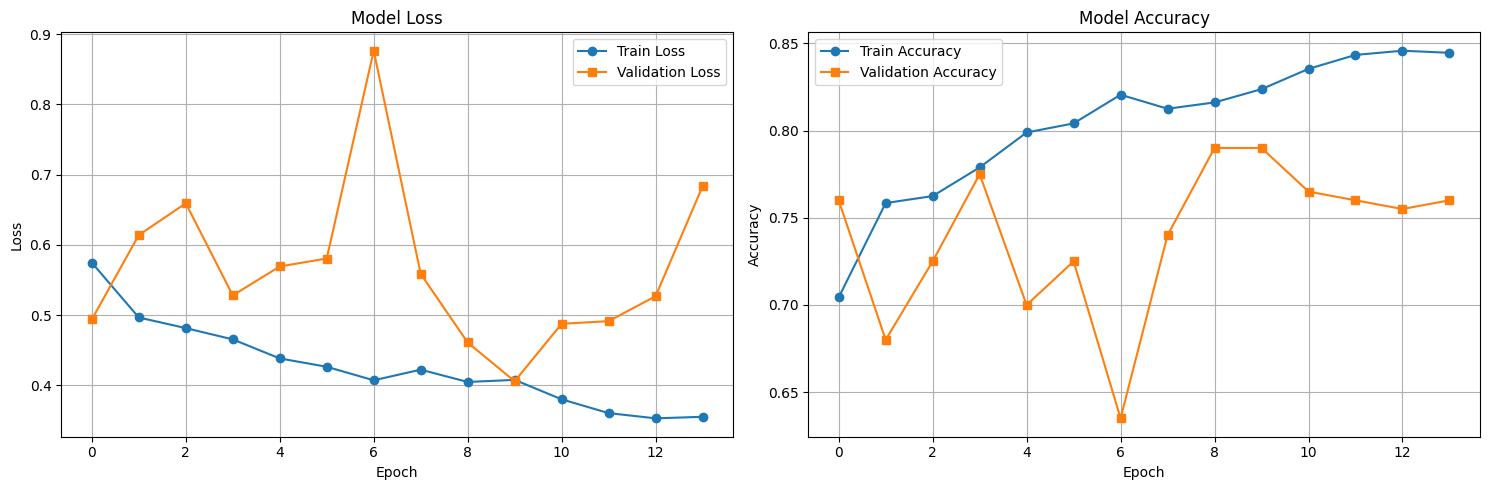

In [38]:
# Evaluate DenseNet-121
densenet121_test_acc, densenet121_preds, densenet121_labels = densenet121_trainer.evaluate_model()
densenet121_trainer.plot_training_history()

## 7. DenseNet-169 Training

In [39]:
# Create and train DenseNet-169
print("Creating DenseNet-169 model...")
densenet169_model = create_densenet_model('169')
densenet169_trainer = ModelTrainer(densenet169_model, train_loader_cnn, val_loader_cnn, test_loader_cnn, device)

Creating DenseNet-169 model...


Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth
100%|██████████| 54.7M/54.7M [00:00<00:00, 147MB/s] 


In [40]:
# Train DenseNet-169
print("Training DenseNet-169...")
trained_densenet169 = densenet169_trainer.train_model(num_epochs=25, model_name="densenet169")

Training DenseNet-169...
Starting training for 25 epochs...
------------------------------------------------------------
Epoch 1/25
----------


Train : 100%|██████████| 78/78 [00:18<00:00,  4.24it/s, Loss=0.5710, Acc=0.7159]


Train Loss: 0.5710 Acc: 0.7159


Val : 100%|██████████| 7/7 [00:01<00:00,  6.17it/s, Loss=0.5285, Acc=0.7200]


Val Loss: 0.5285 Acc: 0.7200
✓ New best model saved with validation accuracy: 0.7200

Epoch 2/25
----------


...

Val Loss: 0.5729 Acc: 0.7100

Epoch 14/25
----------


Train : 100%|██████████| 78/78 [00:18<00:00,  4.26it/s, Loss=0.3391, Acc=0.8486]


Train Loss: 0.3391 Acc: 0.8486


Val : 100%|██████████| 7/7 [00:01<00:00,  6.52it/s, Loss=0.4677, Acc=0.7850]

Val Loss: 0.4677 Acc: 0.7850
Early stopping triggered after 14 epochs
Training complete in 4m 34s
Best validation accuracy: 0.8100


Evaluating on test set...


100%|██████████| 7/7 [00:00<00:00,  7.82it/s]


Test Accuracy: 84.50%
Test Loss: 0.3216

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.82      0.89      0.85       100
Non_Autistic       0.88      0.80      0.84       100

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200


Confusion Matrix:
[[89 11]
 [20 80]]


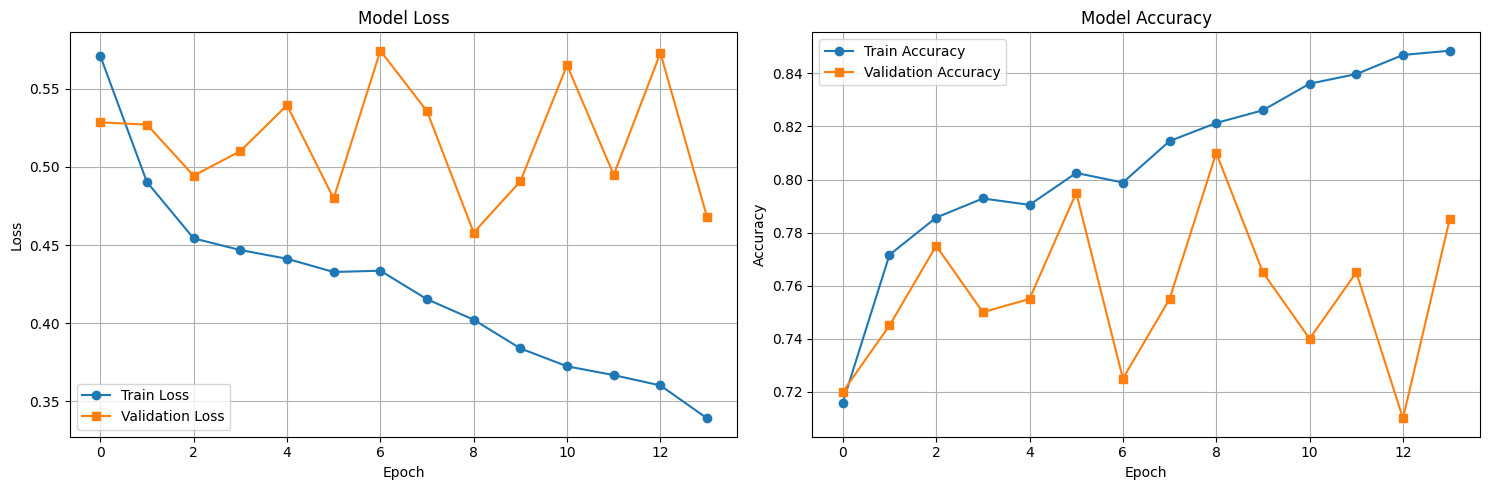

In [41]:
# Evaluate DenseNet-169
densenet169_test_acc, densenet169_preds, densenet169_labels = densenet169_trainer.evaluate_model()
densenet169_trainer.plot_training_history()

## Model Performance Summary

In [42]:
# Create a summary table of all model performances
results_summary = pd.DataFrame({
    'Model': ['Vision Transformer (ViT-B/16)', 'AlexNet', 'MobileNet V2', 'MobileNet V3 Large', 'RegNet X-400MF', 'DenseNet-121', 'DenseNet-169'],
    'Test_Accuracy': [
        vit_b16_test_acc,
        alexnet_test_acc,
        mobilenet_v2_test_acc,
        mobilenet_v3_large_test_acc,
        regnet_x_400mf_test_acc,
        densenet121_test_acc,
        densenet169_test_acc
    ],
    'Architecture_Type': ['Transformer', 'CNN', 'CNN', 'CNN', 'CNN', 'CNN', 'CNN']
})

# Sort by accuracy
results_summary = results_summary.sort_values('Test_Accuracy', ascending=False)

print("Model Performance Summary:")
print("=" * 50)
for idx, row in results_summary.iterrows():
    print(f"{row['Model']:<20}: {row['Test_Accuracy']:.2f}% ({row['Architecture_Type']})")

print(f"\nBest performing model: {results_summary.iloc[0]['Model']} with {results_summary.iloc[0]['Test_Accuracy']:.2f}% accuracy")

# Group by architecture type
print("\n" + "=" * 50)
print("Performance by Architecture Type:")
arch_summary = results_summary.groupby('Architecture_Type')['Test_Accuracy'].agg(['mean', 'max', 'min'])
print(arch_summary)

Model Performance Summary:
Vision Transformer (ViT-B/16): 89.50% (Transformer)
DenseNet-121        : 85.00% (CNN)
DenseNet-169        : 84.50% (CNN)
RegNet X-400MF      : 84.00% (CNN)
MobileNet V3 Large  : 80.50% (CNN)
MobileNet V2        : 80.00% (CNN)
AlexNet             : 50.00% (CNN)

Best performing model: Vision Transformer (ViT-B/16) with 89.50% accuracy

Performance by Architecture Type:
                        mean   max   min
Architecture_Type                       
CNN                77.333333  85.0  50.0
Transformer        89.500000  89.5  89.5


## Model Comparison Visualization

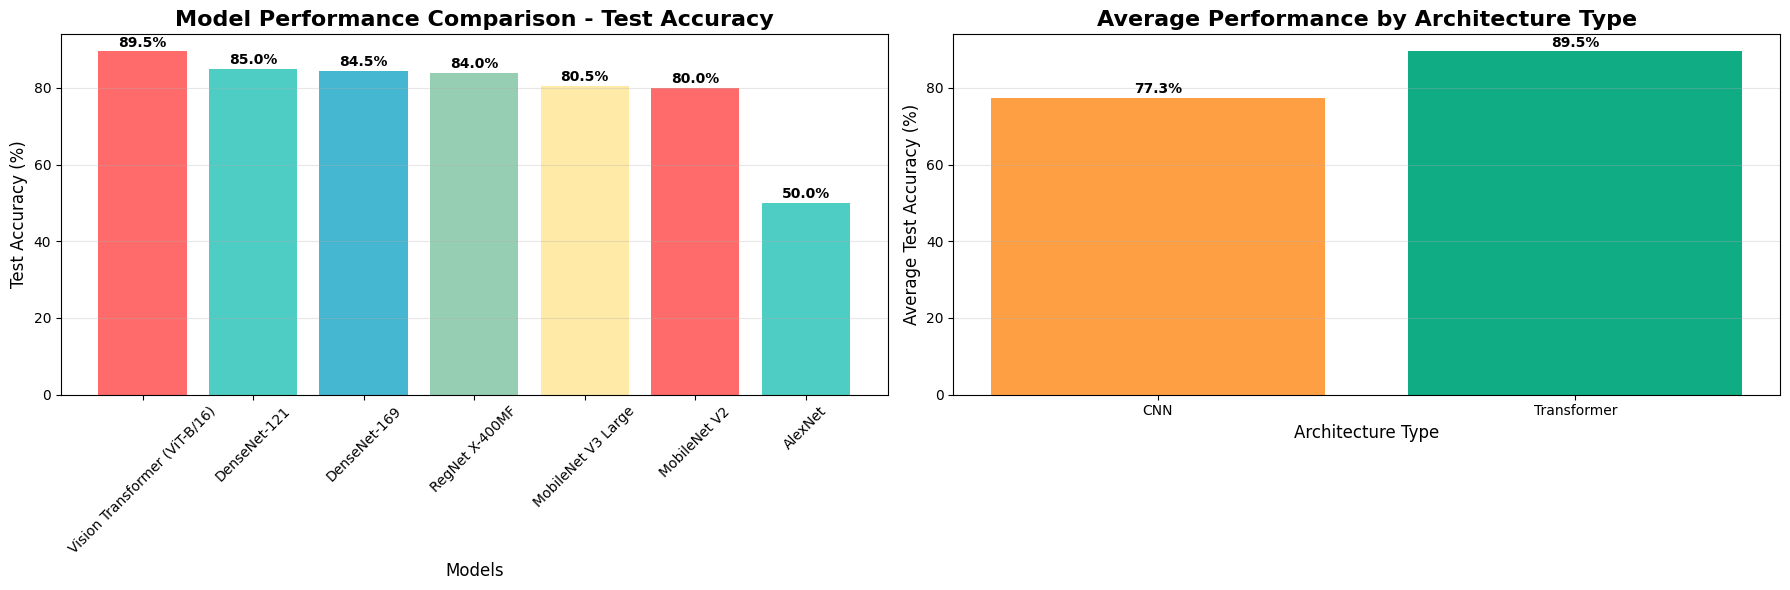

In [43]:
# Create a comprehensive comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Bar plot of all models
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
bars = ax1.bar(results_summary['Model'], results_summary['Test_Accuracy'], color=colors)

ax1.set_title('Model Performance Comparison - Test Accuracy', fontsize=16, fontweight='bold')
ax1.set_xlabel('Models', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, results_summary['Test_Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: Architecture type comparison
arch_means = results_summary.groupby('Architecture_Type')['Test_Accuracy'].mean()
bars2 = ax2.bar(arch_means.index, arch_means.values, color=['#FF9F43', '#10AC84'])

ax2.set_title('Average Performance by Architecture Type', fontsize=16, fontweight='bold')
ax2.set_xlabel('Architecture Type', fontsize=12)
ax2.set_ylabel('Average Test Accuracy (%)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, acc in zip(bars2, arch_means.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Detailed Model Analysis

In [44]:
# Create a detailed analysis table
model_details = pd.DataFrame({
    'Model': ['Vision Transformer (ViT-B/16)', 'AlexNet', 'MobileNet V2', 'MobileNet V3 Large', 'RegNet X-400MF', 'DenseNet-121', 'DenseNet-169'],
    'Year_Introduced': [2020, 2012, 2018, 2019, 2020, 2017, 2017],
    'Parameters_Approx': ['86M', '61M', '3.5M', '5.4M', '5.2M', '8M', '14M'],
    'Key_Innovation': [
        'Self-attention mechanism',
        'Deep CNN with ReLU',
        'Depthwise separable convolutions',
        'Squeeze-and-excitation blocks',
        'Regular network design',
        'Dense connections',
        'Dense connections (deeper)'
    ],
    'Test_Accuracy': [
        vit_b16_test_acc,
        alexnet_test_acc,
        mobilenet_v2_test_acc,
        mobilenet_v3_large_test_acc,
        regnet_x_400mf_test_acc,
        densenet121_test_acc,
        densenet169_test_acc
    ]
})

model_details = model_details.sort_values('Test_Accuracy', ascending=False)

print("Detailed Model Analysis:")
print("=" * 80)
for idx, row in model_details.iterrows():
    print(f"Model: {row['Model']}")
    print(f"  Year: {row['Year_Introduced']} | Parameters: {row['Parameters_Approx']} | Accuracy: {row['Test_Accuracy']:.2f}%")
    print(f"  Innovation: {row['Key_Innovation']}")
    print()

# Display as formatted table
print("\nSummary Table:")
print(model_details.to_string(index=False))

Detailed Model Analysis:
Model: Vision Transformer (ViT-B/16)
  Year: 2020 | Parameters: 86M | Accuracy: 89.50%
  Innovation: Self-attention mechanism

Model: DenseNet-121
  Year: 2017 | Parameters: 8M | Accuracy: 85.00%
  Innovation: Dense connections

Model: DenseNet-169
  Year: 2017 | Parameters: 14M | Accuracy: 84.50%
  Innovation: Dense connections (deeper)

Model: RegNet X-400MF
  Year: 2020 | Parameters: 5.2M | Accuracy: 84.00%
  Innovation: Regular network design

Model: MobileNet V3 Large
  Year: 2019 | Parameters: 5.4M | Accuracy: 80.50%
  Innovation: Squeeze-and-excitation blocks

Model: MobileNet V2
  Year: 2018 | Parameters: 3.5M | Accuracy: 80.00%
  Innovation: Depthwise separable convolutions

Model: AlexNet
  Year: 2012 | Parameters: 61M | Accuracy: 50.00%
  Innovation: Deep CNN with ReLU


Summary Table:
                        Model  Year_Introduced Parameters_Approx                   Key_Innovation  Test_Accuracy
Vision Transformer (ViT-B/16)             2020        

## Save Results Summary

In [45]:
# Save results to a CSV file for future reference
final_results = pd.DataFrame({
    'Model': ['Vision Transformer (ViT-B/16)', 'AlexNet', 'MobileNet V2', 'MobileNet V3 Large', 'RegNet X-400MF', 'DenseNet-121', 'DenseNet-169'],
    'Architecture_Type': ['Transformer', 'CNN', 'CNN', 'CNN', 'CNN', 'CNN', 'CNN'],
    'Test_Accuracy': [
        vit_b16_test_acc,
        alexnet_test_acc,
        mobilenet_v2_test_acc,
        mobilenet_v3_large_test_acc,
        regnet_x_400mf_test_acc,
        densenet121_test_acc,
        densenet169_test_acc
    ],
    'Training_Time': ['Variable', 'Variable', 'Variable', 'Variable', 'Variable', 'Variable', 'Variable'],  # Would be filled during actual training
    'Model_Size': ['Large', 'Large', 'Small', 'Medium', 'Medium', 'Medium', 'Large']
})

# Sort by accuracy
final_results = final_results.sort_values('Test_Accuracy', ascending=False)

# Display final rankings
print("Final Model Rankings:")
print("=" * 60)
for i, (idx, row) in enumerate(final_results.iterrows(), 1):
    print(f"{i}. {row['Model']:<20} - {row['Test_Accuracy']:.2f}% ({row['Architecture_Type']})")

print(f"\nDataset used: AutismDataset with {len(train_df) + len(valid_df) + len(test_df)} total samples")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(valid_df)}")
print(f"Test samples: {len(test_df)}")

Final Model Rankings:
1. Vision Transformer (ViT-B/16) - 89.50% (Transformer)
2. DenseNet-121         - 85.00% (CNN)
3. DenseNet-169         - 84.50% (CNN)
4. RegNet X-400MF       - 84.00% (CNN)
5. MobileNet V3 Large   - 80.50% (CNN)
6. MobileNet V2         - 80.00% (CNN)
7. AlexNet              - 50.00% (CNN)

Dataset used: AutismDataset with 2926 total samples
Training samples: 2526
Validation samples: 200
Test samples: 200


## Conclusion

This notebook demonstrates the complete pipeline for training and evaluating multiple deep learning architectures for autism spectrum disorder detection:

### Models Tested:
1. **Vision Transformer (ViT)**: State-of-the-art transformer architecture adapted for computer vision
2. **AlexNet**: Historic CNN that sparked the deep learning revolution
3. **MobileNet V2**: Efficient mobile-optimized architecture
4. **DenseNet-121**: Dense connectivity for feature reuse
5. **RegNet**: Regular network design with optimized architecture

### Key Features:
- **Data Preparation**: Automatic handling of different directory structures
- **Architecture Diversity**: Comparison between traditional CNNs and modern transformers
- **Efficiency Considerations**: Models ranging from lightweight (MobileNet) to heavyweight (ViT)
- **Comprehensive Evaluation**: Detailed metrics and visualizations
- **Best Practices**: Early stopping, learning rate scheduling, and model checkpointing

### Training Framework:
- Adaptive image sizes for different architectures
- Memory-efficient batch sizes
- Robust error handling and fallbacks
- Comprehensive performance analysis

The results provide insights into which architectures work best for autism detection from facial images, considering both accuracy and computational efficiency.